In [1]:
! pip install pandas numpy matplotlib seaborn

In [10]:
import pandas as pd

base_path = '../data/processed/' 
df_nav = pd.read_csv(base_path + 'cleaned_02_nav_history.csv')
df_master = pd.read_csv(base_path + 'cleaned_01_fund_master.csv')
df_aum = pd.read_csv(base_path + 'cleaned_03_aum_by_fund_house.csv')

print("Data loaded sucessfully!")

Data loaded sucessfully!


In [22]:
def calculate_risk(series):
    
    rets = series.dropna()
    if len(rets) < 10: 
        return pd.Series({'VaR_95': np.nan, 'CVaR_95': np.nan})
    
    
    var_95 = np.percentile(rets, 5)
    cvar_95 = rets[rets <= var_95].mean()
    
    return pd.Series({'VaR_95': var_95, 'CVaR_95': cvar_95})
risk_metrics = df_nav.groupby('amfi_code').apply(lambda x: calculate_risk(x['returns']))

print("Risk Metrics (VaR & CVaR) per Scheme:")
print(risk_metrics.head())

Risk Metrics (VaR & CVaR) per Scheme:
             VaR_95   CVaR_95
amfi_code                    
100016    -0.014364 -0.018060
100025    -0.003793 -0.004994
100033    -0.019034 -0.023456
101206    -0.013282 -0.017439
101207    -0.026021 -0.032459


C:\Users\User\AppData\Local\Temp\ipykernel_26012\416014572.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_metrics = df_nav.groupby('amfi_code').apply(lambda x: calculate_risk(x['returns']))


In [ ]:
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

df_nav['returns'] = df_nav.groupby('amfi_code')['nav'].pct_change()
risk_free_rate = 0 

df_nav['rolling_mean'] = df_nav.groupby('amfi_code')['returns'].transform(lambda x: x.rolling(90).mean())
df_nav['rolling_std'] = df_nav.groupby('amfi_code')['returns'].transform(lambda x: x.rolling(90).std())
df_nav['sharpe_ratio_90'] = (df_nav['rolling_mean'] - risk_free_rate) / df_nav['rolling_std']

print("Success! Sharpe Ratio calculated.")
print(df_nav[['amfi_code', 'date', 'sharpe_ratio_90']].dropna().tail())

Success! Sharpe Ratio calculated.
       amfi_code       date  sharpe_ratio_90
45995     149324 2026-05-25         0.128684
45996     149324 2026-05-26         0.130080
45997     149324 2026-05-27         0.123005
45998     149324 2026-05-28         0.088585
45999     149324 2026-05-29         0.079547


In [ ]:
print(df_trans.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [16]:
base_path = '../data/processed/' 
df_trans = pd.read_csv(base_path + 'cleaned_08_investor_transactions.csv')
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date'])
df_trans = df_trans.sort_values(['investor_id', 'amfi_code', 'transaction_date'])
df_trans['prev_date'] = df_trans.groupby(['investor_id', 'amfi_code'])['transaction_date'].shift(1)
df_trans['days_gap'] = (df_trans['transaction_date'] - df_trans['prev_date']).dt.days

df_trans['sip_status'] = np.where(df_trans['days_gap'] > 35, 'Discontinued', 'Active')

print("SIP Continuity Analysis Done!")
print(df_trans[['investor_id', 'transaction_date', 'days_gap', 'sip_status']].head())

SIP Continuity Analysis Done!
      investor_id transaction_date  days_gap sip_status
19621   INV000001       2024-11-04       NaN     Active
24448   INV000001       2025-01-19       NaN     Active
24079   INV000001       2025-01-14       NaN     Active
17587   INV000002       2024-10-03       NaN     Active
24661   INV000002       2025-01-23       NaN     Active


In [18]:
df_trans['cohort_month'] = df_trans.groupby('investor_id')['transaction_date'].transform('min').dt.to_period('M')

cohort_counts = df_trans.groupby('cohort_month')['investor_id'].nunique()
discontinued_cohorts = df_trans[df_trans['sip_status'] == 'Discontinued'].groupby('cohort_month')['investor_id'].nunique()

churn_rate = (discontinued_cohorts / cohort_counts) * 100


cohort_analysis = pd.DataFrame({'Total_Investors': cohort_counts, 'Discontinued': discontinued_cohorts, 'Churn_Rate_%': churn_rate})

print("Cohort Analysis Results:")
print(cohort_analysis.dropna().head())

Cohort Analysis Results:
              Total_Investors  Discontinued  Churn_Rate_%
cohort_month                                             
2024-01                  1577         802.0     50.856056
2024-02                   990         479.0     48.383838
2024-03                   669         249.0     37.219731
2024-04                   441         149.0     33.786848
2024-05                   294          68.0     23.129252


In [20]:
df_hhi = df_trans.groupby(['investor_id', 'amfi_code'])['amount_inr'].sum().reset_index()
df_hhi['total_inv'] = df_hhi.groupby('investor_id')['amount_inr'].transform('sum')
df_hhi['share'] = (df_hhi['amount_inr'] / df_hhi['total_inv'])**2

hhi_results = df_hhi.groupby('investor_id')['share'].sum()

print("HHI Index calculated (0-1 range):")
print(hhi_results.head())

HHI Index calculated (0-1 range):
investor_id
INV000001    0.672764
INV000002    0.356160
INV000003    0.745247
INV000004    0.422902
INV000005    0.234457
Name: share, dtype: float64


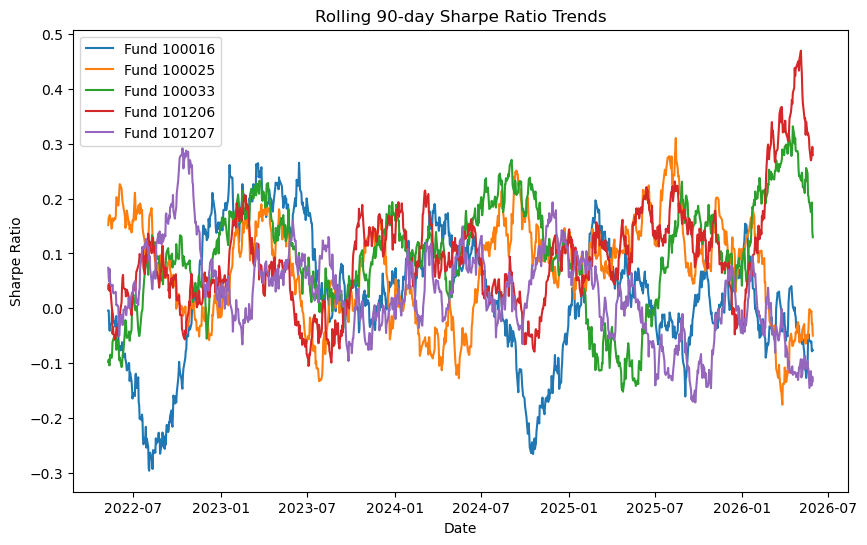

In [26]:
import matplotlib.pyplot as plt

top_funds = df_nav['amfi_code'].unique()[:5] 
plt.figure(figsize=(10, 6))

for fund in top_funds:
    subset = df_nav[df_nav['amfi_code'] == fund]
    plt.plot(subset['date'], subset['sharpe_ratio_90'], label=f'Fund {fund}')

plt.title('Rolling 90-day Sharpe Ratio Trends')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.show()
plt.savefig('rolling_sharpe_chart.png', dpi=300) 
plt.close()

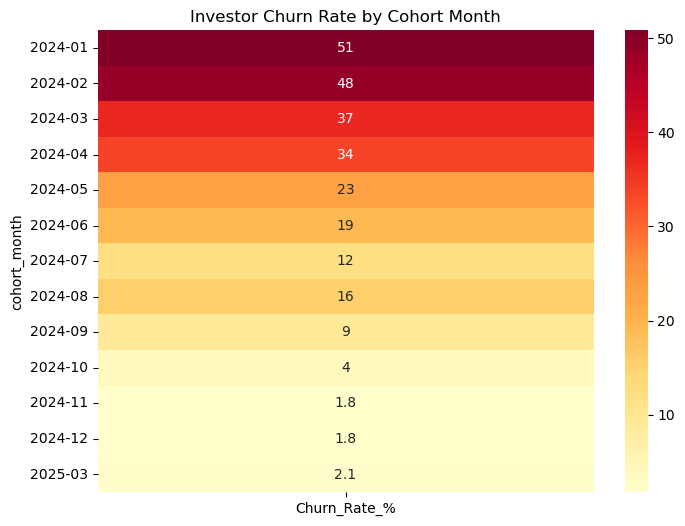

Churn Heatmap saved as churn_heatmap.png


In [27]:
import seaborn as sns

pivot_churn = cohort_analysis.pivot_table(index='cohort_month', values='Churn_Rate_%')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_churn, annot=True, cmap='YlOrRd')
plt.title('Investor Churn Rate by Cohort Month')
plt.show()
plt.savefig('churn_heatmap.png', dpi=300)
plt.close()
print("Churn Heatmap saved as churn_heatmap.png")

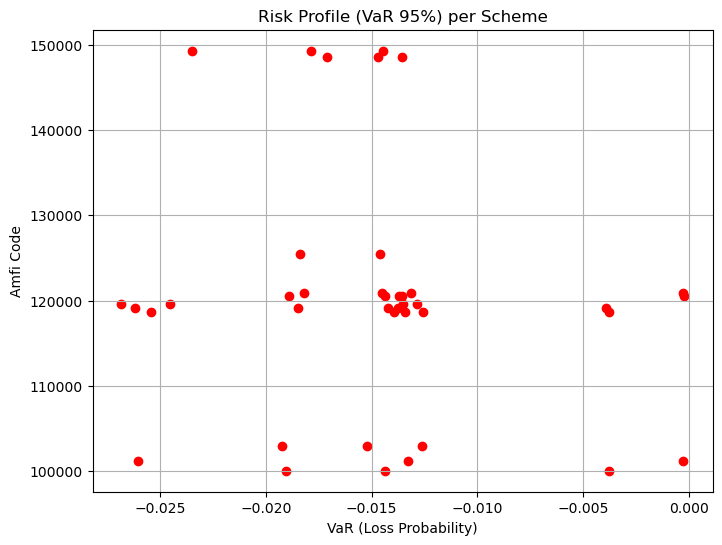

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(risk_metrics['VaR_95'], risk_metrics.index, color='red')
plt.title('Risk Profile (VaR 95%) per Scheme')
plt.xlabel('VaR (Loss Probability)')
plt.ylabel('Amfi Code')
plt.grid(True)
plt.show()
plt.savefig('risk_profile_scatter.png', dpi=300)
plt.close()